## 0. Tiền xử lý dữ liệu

Import các thư viện xử lý dữ liệu lưới và các công cụ học máy (Scikit-learn) để phân tích hồi quy đa biến về các driver của đối lưu.

In [1]:
import os
import gc
import numpy as np
import pandas as pd
import xarray as xr
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False
folder_path = r'D:\clone\merged'

Xây dựng hàm xử lý các chỉ số bất ổn định đối lưu từ ERA5. Trong phân tích này, chúng ta sử dụng bộ ba chỉ số quan trọng:
- **CAPE (Convective Available Potential Energy)**: Năng lượng tiềm năng đối lưu (J/kg), đo lường năng lượng sẵn có để đẩy các khối khí lên cao.
- **K-index (KI)**: Chỉ số đo lường tiềm năng dông bão dựa trên nhiệt độ thẳng đứng và độ ẩm tầng thấp.
- **Total Totals Index (TT)**: Chỉ số dự báo thời tiết nguy hiểm dựa trên sự chênh lệch nhiệt độ giữa các tầng khí quyển.
- **CII (Composite Instability Index)**: Chỉ số đối lưu tổng hợp được tính bằng cách chuẩn hóa (Z-score) và trung bình hóa cả 3 chỉ số trên để có cái nhìn toàn diện về độ bất ổn định của khí quyển.
- **Severe**: Ngưỡng định nghĩa ngày có đối lưu mạnh khi chỉ số CII > 1.0.

In [2]:
def standardise(df):
    return (df - df.mean()) / (df.std() + 1e-9)

def load_and_aggregate_instability(cape_f, ki_f, tt_f):
    def preprocess(ds):
        if 'valid_time' in ds.coords: ds = ds.rename({'valid_time': 'time'})
        if 'expver' in ds.dims: ds = ds.mean(dim='expver')
        return ds.sortby('time')

    files = [cape_f, ki_f, tt_f]
    keys = ['cape', 'ki', 'tt']
    df_daily = pd.DataFrame()
    raw_data = {}

    for f, k in zip(files, keys):
        ds = preprocess(xr.open_dataset(os.path.join(folder_path, f)))
        var = list(ds.data_vars)[0]
        ts = ds[var].mean(dim=['latitude', 'longitude']).compute()
        raw_data[k] = ts
        df_daily[k] = ts.resample(time='1D').max().values
        if k == 'cape': df_daily.index = ts.resample(time='1D').max().time.values
        ds.close(); gc.collect()

    df_daily['cii'] = (standardise(df_daily['cape']) + standardise(df_daily['ki']) + standardise(df_daily['tt'])) / 3.0
    
    df_daily['severe'] = (df_daily['cii'] > 1.0).astype(float)
    
    df_monthly = df_daily.resample('ME').mean()
    df_yearly = df_daily.resample('YS').mean()
    clim = df_monthly.groupby(df_monthly.index.month).mean()
    
    df_monthly['month'] = df_monthly.index.month
    df_monthly['year'] = df_monthly.index.year
    df_monthly['cii_anom'] = df_monthly['cii'] - df_monthly['month'].map(clim['cii'])
    df_monthly['cape_anom'] = df_monthly['cape'] - df_monthly['month'].map(clim['cape'])

    return df_daily, df_monthly, df_yearly, clim, raw_data

Thực thi nạp dữ liệu và tính toán các chỉ số bất ổn định đối lưu.

In [3]:
c_f = 'convective_available_potential_energy (CAPE)_merged.nc'
k_f = 'k_index_merged.nc'
t_f = 'total_totals_index_merged.nc'

df_daily, df_monthly, df_yearly, clim, raw = load_and_aggregate_instability(c_f, k_f, t_f)
df_monthly.head()

,cape,ki,tt,cii,severe,month,year,cii_anom,cape_anom
1980-01-31,29.902786,8.092877,35.962696,-1.454254,0.000000,1,1980,-0.171727,-10.357895
1980-02-29,120.765549,20.567781,40.086693,-0.638103,0.000000,2,1980,0.229217,4.770645
1980-03-31,478.301025,25.878130,42.899925,-0.043525,0.000000,3,1980,0.198893,88.085876
1980-04-30,962.939209,30.002392,43.399277,0.390885,0.066667,4,1980,-0.021894,-26.494812
1980-05-31,1523.421509,33.994019,44.245235,0.886895,0.451613,5,1980,0.119694,104.204102


## 1. Chu kỳ mùa của các chỉ số đối lưu

Do các chỉ số `CAPE`, `KI`, và `TT` có đơn vị và thang đo khác nhau, chúng ta thực hiện chuẩn hóa Min-Max (0-1) để so sánh chu kỳ mùa của chúng trên cùng một biểu đồ. 

Sự đồng bộ giữa các chỉ số này thường xảy ra vào giai đoạn chuyển tiếp gió mùa, khi năng lượng nhiệt và độ ẩm cùng đạt mức cao nhất, tạo điều kiện thuận lợi cho các hiện tượng đối lưu mạnh.

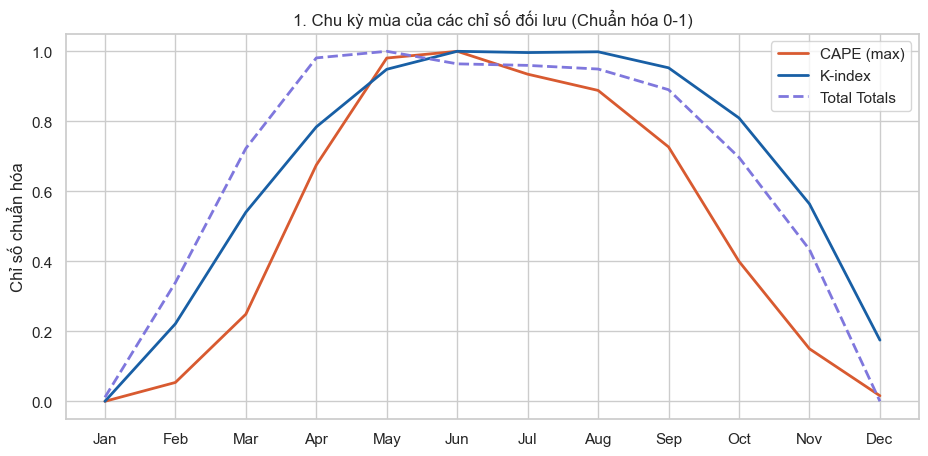

In [4]:
def minmax(s): return (s - s.min()) / (s.max() - s.min() + 1e-9)

plt.figure(figsize=(11, 5))
plt.plot(clim.index, minmax(clim['cape']), color='#D85A30', lw=2, label='CAPE (max)')
plt.plot(clim.index, minmax(clim['ki']), color='#185FA5', lw=2, label='K-index')
plt.plot(clim.index, minmax(clim['tt']), color='#7F77DD', lw=2, ls='--', label='Total Totals')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.title("1. Chu kỳ mùa của các chỉ số đối lưu (Chuẩn hóa 0-1)")
plt.ylabel("Chỉ số chuẩn hóa")
plt.legend()
plt.show()

## 2. Xu hướng dài hạn của các chỉ số bất ổn định

Biểu đồ cho thấy các chỉ số bất ổn định không có xu hướng tăng đồng nhất theo thời gian.

- CAPE có xu hướng giảm nhẹ, cho thấy năng lượng đối lưu không tăng rõ rệt.
- CII gần như không thay đổi đáng kể.
- K-index tăng nhẹ (có ý nghĩa thống kê), phản ánh môi trường khí quyển có xu hướng ẩm và bất ổn hơn.
- Total Totals giảm nhẹ nhưng chưa đủ ý nghĩa.

Nhìn chung, chưa có dấu hiệu rõ ràng cho thấy khí quyển trở nên “năng lượng hơn”, nhưng có sự thay đổi về đặc tính nhiệt ẩm của môi trường khí quyển theo thời gian.

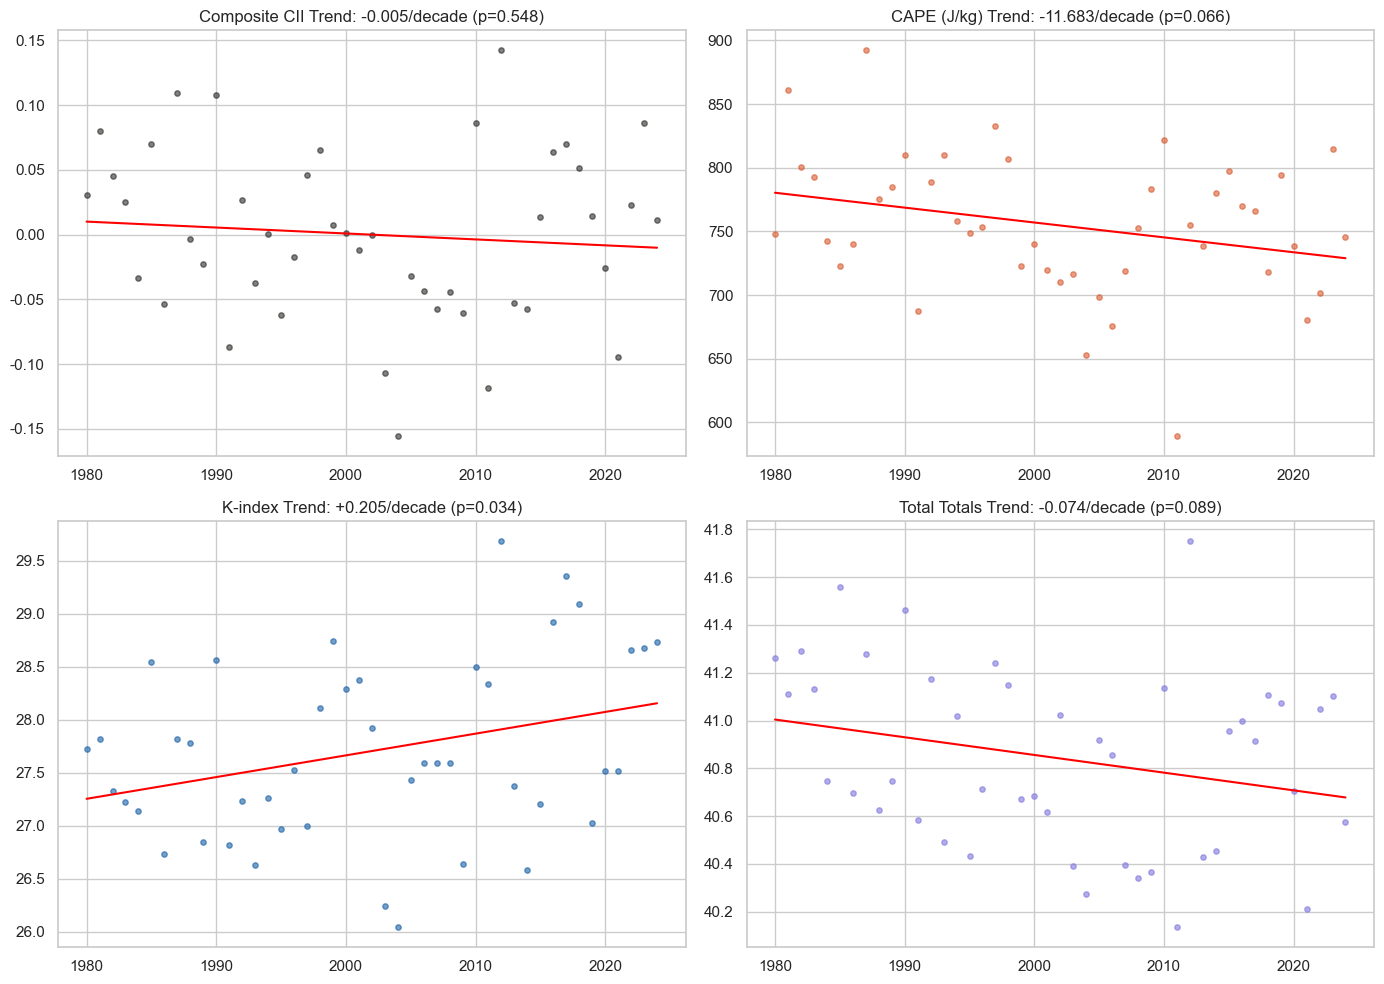

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = [('cii', 'Composite CII', '#2C2C2A'), ('cape', 'CAPE (J/kg)', '#D85A30'), 
           ('ki', 'K-index', '#185FA5'), ('tt', 'Total Totals', '#7F77DD')]

for ax, (col, label, color) in zip(axes.flatten(), metrics):
    y = df_yearly[col].values
    x = df_yearly.index.year.values
    slope, intercept, r, p, _ = stats.linregress(x, y)
    ax.scatter(x, y, s=15, color=color, alpha=0.6)
    ax.plot(x, intercept + slope * x, color='red', lw=1.5)
    ax.set_title(f"{label} Trend: {slope*10:+.3f}/decade (p={p:.3f})")
plt.tight_layout()
plt.show()

## 3. Ma trận dị thường chỉ số đối lưu tổng hợp (CII)

Heatmap theo dõi các giai đoạn bất ổn định bất thường của khí quyển. 
- **Vùng màu đỏ**: Những năm/tháng có tiềm năng dông bão và thời tiết nguy hiểm cao hơn trung bình lịch sử.
- **Vùng màu xanh**: Giai đoạn khí quyển ổn định hơn bình thường.

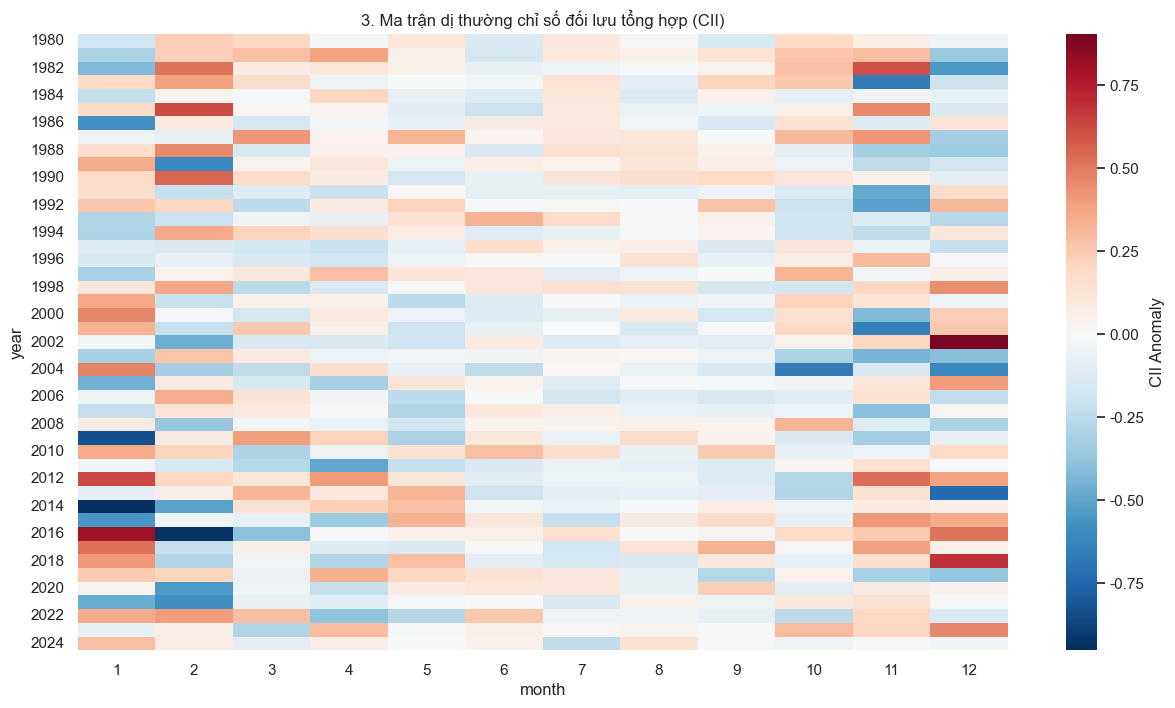

In [6]:
pivot = df_monthly.pivot(index='year', columns='month', values='cii_anom')
plt.figure(figsize=(15, 8))
sns.heatmap(pivot, cmap="RdBu_r", center=0, cbar_kws={'label': 'CII Anomaly'})
plt.title("3. Ma trận dị thường chỉ số đối lưu tổng hợp (CII)")
plt.show()

## 4. Tần suất ngày đối lưu mạnh

Biểu đồ thống kê số ngày trong năm mà cả 3 chỉ số đối lưu đồng thời vượt ngưỡng cao ($CII > 1$). Đây là thước đo trực tiếp về sự thay đổi tần suất xuất hiện của các hình thế thời tiết cực đoan (Severe Weather) qua các thập kỷ.

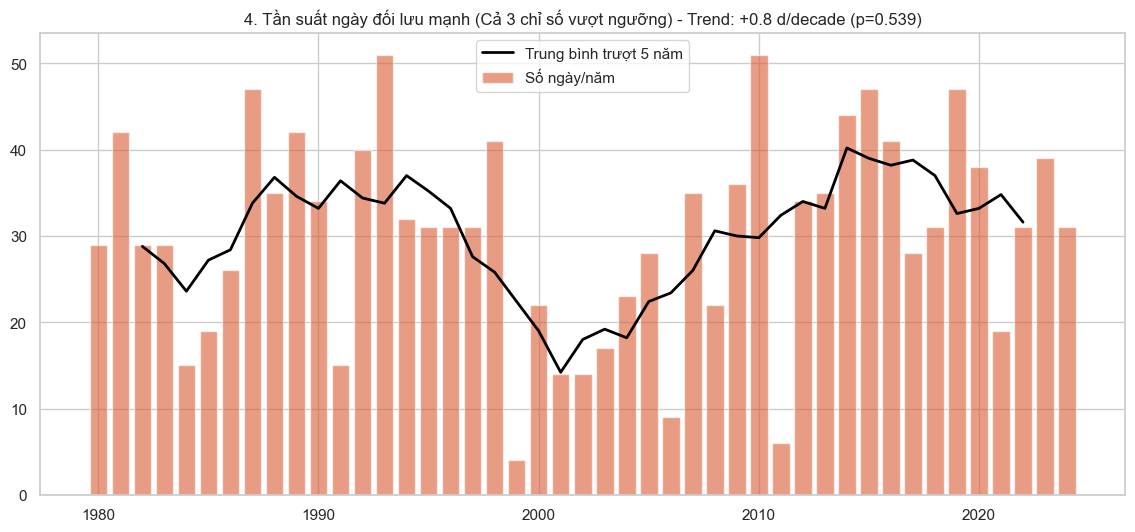

In [7]:
annual_sev = df_daily['severe'].resample('YS').sum()
x = annual_sev.index.year
y = annual_sev.values

plt.figure(figsize=(14, 6))
plt.bar(x, y, color='#D85A30', alpha=0.6, label='Số ngày/năm')
plt.plot(x, pd.Series(y).rolling(5, center=True).mean(), color='black', lw=2, label='Trung bình trượt 5 năm')
slope, _, _, p, _ = stats.linregress(x, y)
plt.title(f"4. Tần suất ngày đối lưu mạnh (Cả 3 chỉ số vượt ngưỡng) - Trend: {slope*10:+.1f} d/decade (p={p:.3f})")
plt.legend()
plt.show()

## 5. Cấu trúc nhiệt động lực học theo mùa

Sử dụng biểu đồ Hexbin để quan sát sự phân bố không gian pha giữa `CAPE` và `K-index`, với màu sắc đại diện cho chỉ số `Total Totals`. 
Mỗi mùa có một "vùng nhận diện" (signature) riêng biệt trên biểu đồ, phản ánh sự thay đổi trong cấu trúc nhiệt - ẩm của cột khí quyển giữa các thời điểm trong năm.

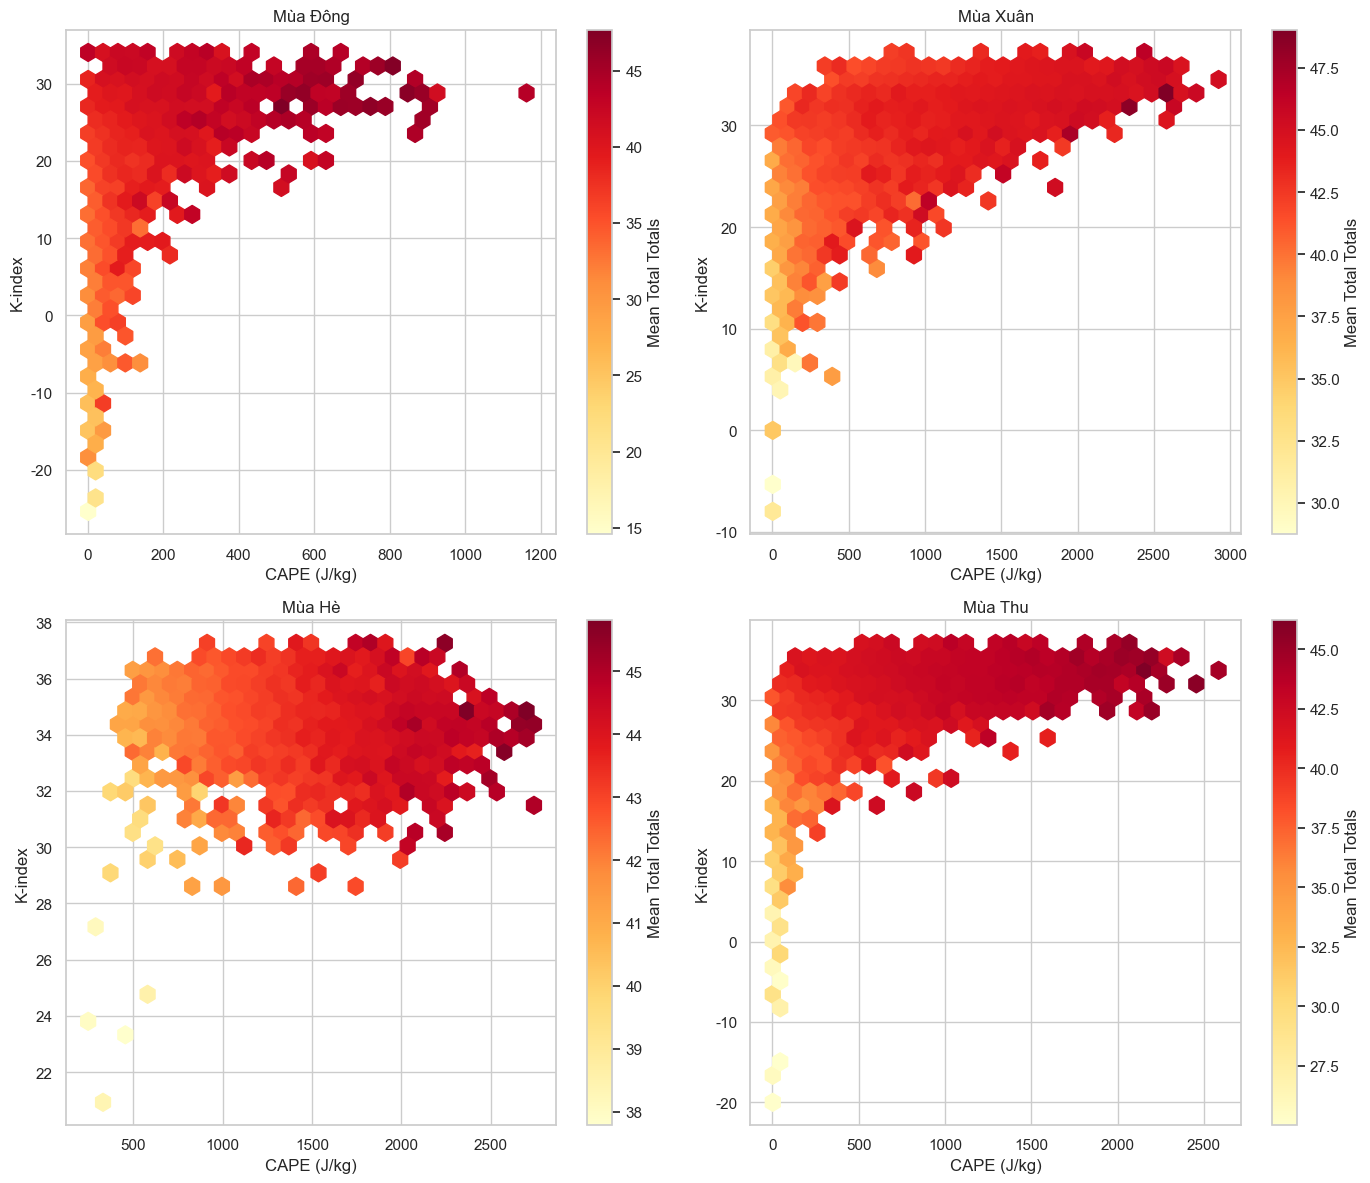

In [8]:
df_daily['month'] = df_daily.index.month
df_daily['season'] = df_daily['month'].map({
    12:'DJF', 1:'DJF', 2:'DJF',
    3:'MAM', 4:'MAM', 5:'MAM',
    6:'JJA', 7:'JJA', 8:'JJA',
    9:'SON', 10:'SON', 11:'SON'
})

season_name = {
    'DJF': 'Đông',
    'MAM': 'Xuân',
    'JJA': 'Hè',
    'SON': 'Thu'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, season in zip(axes.flatten(), ['DJF', 'MAM', 'JJA', 'SON']):
    subset = df_daily[df_daily['season'] == season]
    hb = ax.hexbin(subset['cape'], subset['ki'], C=subset['tt'],
                   gridsize=30, cmap='YlOrRd')

    ax.set_title(f"Mùa {season_name[season]}")
    ax.set_xlabel("CAPE (J/kg)")
    ax.set_ylabel("K-index")

    plt.colorbar(hb, ax=ax, label='Mean Total Totals')

plt.tight_layout()
plt.show()

## 6. Phân tách đóng góp vào xu hướng CAPE

Sử dụng mô hình hồi quy tuyến tính để xác định xem sự thay đổi của `CAPE` bị chi phối bởi yếu tố nào nhiều hơn:
- **Nhiệt độ (T2m)**: Đóng góp thông qua nhiệt năng.
- **Điểm sương (Td)**: Đóng góp thông qua độ ẩm.
Kết quả giúp làm rõ liệu sự gia tăng bất ổn định khí quyển là do quá trình nóng lên (Thermodynamic) hay do sự gia tăng nguồn cung độ ẩm.

In [9]:
try:
    df_t2m = pd.read_csv(os.path.join(folder_path, 'df_monthly_t2m.csv'), index_col=0, parse_dates=True)
    df_td = pd.read_csv(os.path.join(folder_path, 'df_monthly_td.csv'), index_col=0, parse_dates=True)
    
    df_reg = pd.DataFrame({
        'cape_anom': df_monthly['cape_anom'],
        't2m_anom': df_t2m['t2m_anom'],
        'td_anom': df_td['td_anom']
    }).dropna()
    
    model = LinearRegression().fit(df_reg[['t2m_anom', 'td_anom']], df_reg['cape_anom'])
    
    plt.figure(figsize=(8, 5))
    plt.bar(['Nhiệt độ (T2m)', 'Điểm sương (Td)'], model.coef_, color=['#D85A30', '#185FA5'])
    plt.title(f"6. Phân tách đóng góp vào xu hướng CAPE (R²={model.score(df_reg[['t2m_anom', 'td_anom']], df_reg['cape_anom']):.2f})")
    plt.ylabel("Hệ số hồi quy (J/kg per K)")
    plt.show()
except:
    print("Cần dữ liệu T2m và Td từ NB 01/03 để chạy Plot 6")

Cần dữ liệu T2m và Td từ NB 01/03 để chạy Plot 6


## 7. Chu kỳ ngày đêm của CAPE theo mùa

Phân tích biến trình ngày của `CAPE` để xác định thời điểm năng lượng đối lưu đạt đỉnh trong ngày. 
Thông thường, `CAPE` tăng mạnh vào ban ngày sau quá trình nung nóng bề mặt do bức xạ mặt trời.

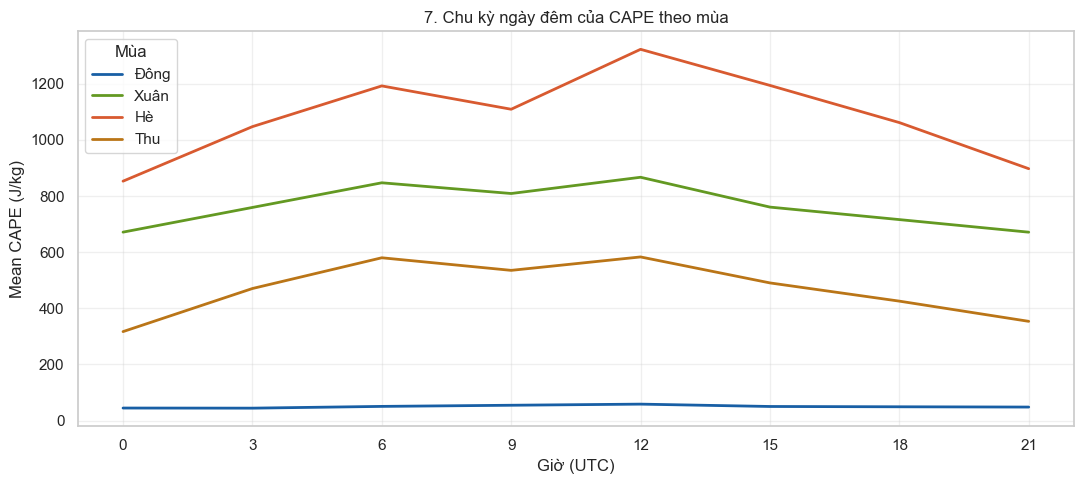

In [10]:
cape_raw = raw['cape']

seasons = {
    'DJF': [12,1,2],
    'MAM': [3,4,5],
    'JJA': [6,7,8],
    'SON': [9,10,11]
}

colors = {
    'DJF': '#185FA5',
    'MAM': '#639922',
    'JJA': '#D85A30',
    'SON': '#BA7517'
}

season_name = {
    'DJF': 'Đông',
    'MAM': 'Xuân',
    'JJA': 'Hè',
    'SON': 'Thu'
}

plt.figure(figsize=(11, 5))

for s_name, s_months in seasons.items():
    subset = cape_raw.sel(time=cape_raw.time.dt.month.isin(s_months))
    diurnal = subset.groupby('time.hour').mean()

    plt.plot(
        diurnal.hour,
        diurnal.values,
        color=colors[s_name],
        lw=2,
        label=season_name[s_name]
    )

plt.title("7. Chu kỳ ngày đêm của CAPE theo mùa")
plt.xlabel("Giờ (UTC)")
plt.ylabel("Mean CAPE (J/kg)")
plt.xticks(range(0, 24, 3))
plt.legend(title="Mùa")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Phân tích đuôi phân phối và độ lệch (Extreme Tail)

Nghiên cứu sự thay đổi của các giá trị cực trị:
- **Phân vị thứ 99 (p99)**: Cho biết các đợt đối lưu mạnh nhất đang thay đổi như thế nào.
- **Tỷ lệ p99/p50**: Đo lường sự "lệch" của phân phối. Nếu tỷ lệ này tăng, điều đó có nghĩa là các hiện tượng cực đoan đang tăng nhanh hơn so với mức trung bình, khiến thời tiết trở nên khó lường hơn.

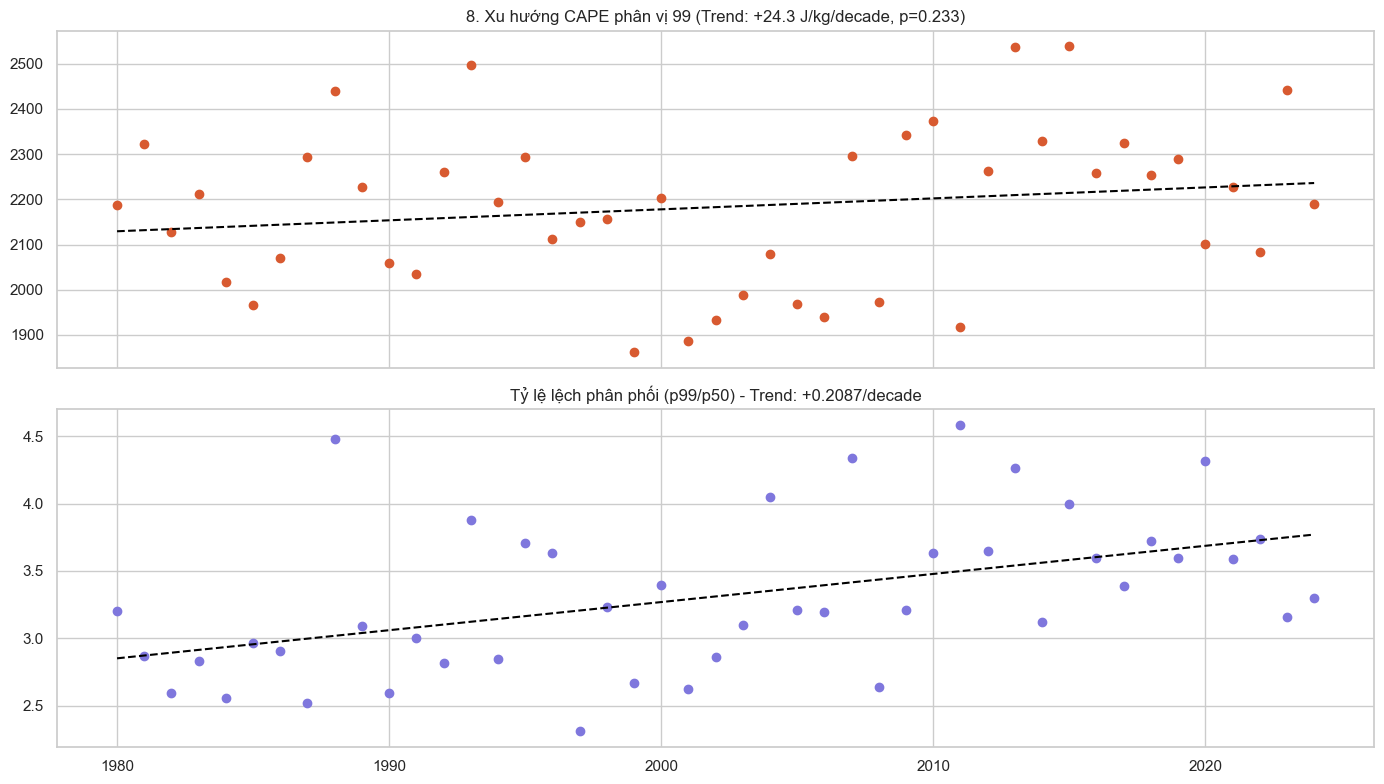

In [11]:
p99 = df_daily['cape'].resample('YS').quantile(0.99)
p50 = df_daily['cape'].resample('YS').quantile(0.50)
skew = p99 / (p50 + 1e-9)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
years = p99.index.year
sl1, ic1, _, p1, _ = stats.linregress(years, p99.values)
ax1.scatter(years, p99.values, color='#D85A30')
ax1.plot(years, ic1 + sl1 * years, color='black', ls='--')
ax1.set_title(f"8. Xu hướng CAPE phân vị 99 (Trend: {sl1*10:+.1f} J/kg/decade, p={p1:.3f})")

sl2, ic2, _, p2, _ = stats.linregress(years, skew.values)
ax2.scatter(years, skew.values, color='#7F77DD')
ax2.plot(years, ic2 + sl2 * years, color='black', ls='--')
ax2.set_title(f"Tỷ lệ lệch phân phối (p99/p50) - Trend: {sl2*10:+.4f}/decade")
plt.tight_layout()
plt.show()

In [13]:
output_dir = r'D:\GitHub\climate-analysis-and-prediction\data\convective_instability'
os.makedirs(output_dir, exist_ok=True)

# ---- Save main DataFrames ----
df_daily.to_parquet(f"{output_dir}/daily.parquet", compression='snappy')
df_monthly.to_parquet(f"{output_dir}/monthly.parquet", compression='snappy')
df_yearly.to_parquet(f"{output_dir}/yearly.parquet", compression='snappy')
clim.to_parquet(f"{output_dir}/climatology.parquet", compression='snappy')


# ---- Convert raw_data (xarray → pandas → parquet) ----
df_raw = pd.DataFrame({
    'cape': raw['cape'].values,
    'ki': raw['ki'].values,
    'tt': raw['tt'].values
}, index=raw['cape'].time.values)

df_raw.to_parquet(f"{output_dir}/raw.parquet", compression='snappy')

print("✅ Saved convective instability (all parquet)")

✅ Saved convective instability (all parquet)
